# M3 — Fine-tuning CheXpert | Center Crop | U-Ones + Label Smoothing
**Projeto Integrador SENAI FATESG 2025/2026**  
Domain Transfer: NIH → CheXpert | U-Ones (-1→+1) | Label Smoothing | Com retomada de checkpoint

## SEÇÃO 0 — Setup e Instalações

In [1]:
!pip install -q tensorflow keras scikit-learn matplotlib pandas numpy

In [2]:
import os, json, time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, optimizers, regularizers

from google.colab import drive
drive.mount('/content/drive')

gpus = tf.config.list_physical_devices('GPU')
print(f'GPUs: {gpus}')
print(f'TensorFlow: {tf.__version__}')

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

Mounted at /content/drive
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TensorFlow: 2.20.0


In [3]:
# ── Caminhos ──────────────────────────────────────────────────────────────────
BASE_DRIVE  = '/content/drive/MyDrive'
CHEX_DIR    = f'{BASE_DRIVE}/datasets_pi_2026/estruturacao/Stanford_Cropping'
TRAIN_CSV   = f'{CHEX_DIR}/chex_crop_train.csv'
VALID_CSV   = f'{CHEX_DIR}/chex_crop_valid.csv'

# Ponto de partida: melhor modelo M2 Crop
M2_CKPT     = f'{BASE_DRIVE}/datasets_pi_2026/modelos/M2_NIH_CheXpert_Crop_UIgnore/m2_crop_final.keras'

OUT_DIR     = f'{BASE_DRIVE}/datasets_pi_2026/modelos/M3_CheXpert_Crop_UOnes'
CKPT_DIR    = f'{OUT_DIR}/checkpoints'
LOG_DIR     = f'{OUT_DIR}/logs'
os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(LOG_DIR,  exist_ok=True)

# ── Labels ────────────────────────────────────────────────────────────────────
LABELS   = ['atelectasis','cardiomegaly','pleural_effusion',
            'pneumothorax','consolidation','edema']
N_LABELS = len(LABELS)

# ── Hiperparâmetros ───────────────────────────────────────────────────────────
IMG_SIZE   = 512
BATCH_SIZE = 32
EPOCHS_P1  = 15    # Fase 1 — frozen (backbone já adaptado ao CheXpert pelo M2)
EPOCHS_P2  = 40    # Fase 2 — unfreeze top 30%
EPOCHS_P3  = 30    # Fase 3 — unfreeze completo
LR_P1      = 1e-3
LR_P2      = 1e-4
LR_P3      = 1e-5
DROPOUT_1  = 0.5
DROPOUT_2  = 0.3
PATIENCE   = 7
PREFIX     = 'm3_crop'

# ── Label Smoothing — variável configurável ───────────────────────────────────
# epsilon=0.05: conservador — incertos convertidos têm target 0.95
# epsilon=0.10: agressivo  — incertos convertidos têm target 0.90
LABEL_SMOOTHING_EPSILON = 0.05   # ← altere aqui: 0.05 ou 0.10

print(f'M2 ckpt  : {M2_CKPT}')
print(f'Out dir  : {OUT_DIR}')
print(f'Epochs   : P1={EPOCHS_P1} | P2={EPOCHS_P2} | P3={EPOCHS_P3} | Total={EPOCHS_P1+EPOCHS_P2+EPOCHS_P3}')
print(f'LS epsilon: {LABEL_SMOOTHING_EPSILON}')
print(f'Existe M2 : {"✅" if os.path.exists(M2_CKPT) else "❌ NÃO ENCONTRADO"}')

M2 ckpt  : /content/drive/MyDrive/datasets_pi_2026/modelos/M2_NIH_CheXpert_Crop_UIgnore/m2_crop_final.keras
Out dir  : /content/drive/MyDrive/datasets_pi_2026/modelos/M3_CheXpert_Crop_UOnes
Epochs   : P1=15 | P2=40 | P3=30 | Total=85
LS epsilon: 0.05
Existe M2 : ✅


## SEÇÃO 1 — Carregamento e Validação dos CSVs

In [9]:
df_train = pd.read_csv(TRAIN_CSV)
df_valid = pd.read_csv(VALID_CSV)

print(f'Train: {len(df_train):,} | Valid: {len(df_valid):,}')

# Valida paths
sample = df_train['img_path'].sample(5, random_state=42).tolist()
print('\nValidação de paths:')
for p in sample:
    print(f'  {"✅" if os.path.exists(p) else "❌"} {p.split("/")[-1]}')

# Distribuição U-Ones — positivos efetivos (confirmados + incertos convertidos)
print('\nDistribuição train (U-Ones — positivos efetivos):')
for lbl in LABELS:
    n_pos_conf = (df_train[f'{lbl}_uones'] == 1).sum()
    n_incertos = df_train[f'{lbl}_uones'].isna().sum()
    # U-Ones: NaN vira 1 → positivos efetivos = confirmados + incertos
    n_neg  = (df_train[f'{lbl}_uones'] == 0).sum()
    print(f'  {lbl:<20}: confirmados={n_pos_conf:>7,} | incertos→+1={n_incertos:>7,} | '
          f'efetivos={n_pos_conf+n_incertos:>7,} | neg={n_neg:>7,}')

Train: 87,258 | Valid: 159

Validação de paths:
  ✅ CheXpert-v1.0_train_patient15426_study40_view1_frontal.png
  ✅ CheXpert-v1.0_train_patient06871_study2_view1_frontal.png
  ✅ CheXpert-v1.0_train_patient32844_study1_view1_frontal.png
  ✅ CheXpert-v1.0_train_patient10968_study5_view1_frontal.png
  ✅ CheXpert-v1.0_train_patient31405_study1_view1_frontal.png

Distribuição train (U-Ones — positivos efetivos):
  atelectasis         : confirmados= 29,173 | incertos→+1= 57,585 | efetivos= 86,758 | neg=    500
  cardiomegaly        : confirmados= 19,457 | incertos→+1= 64,598 | efetivos= 84,055 | neg=  3,203
  pleural_effusion    : confirmados= 40,459 | incertos→+1= 35,722 | efetivos= 76,181 | neg= 11,077
  pneumothorax        : confirmados= 16,023 | incertos→+1= 51,845 | efetivos= 67,868 | neg= 19,390
  consolidation       : confirmados= 19,919 | incertos→+1= 59,180 | efetivos= 79,099 | neg=  8,159
  edema               : confirmados= 30,177 | incertos→+1= 50,114 | efetivos= 80,291 | neg=  6,

## SEÇÃO 2 — Dataset Pipeline com U-Ones

In [10]:
# ── U-Ones: -1 → +1, NaN → 1 ────────────────────────────────────────────────
LABEL_COLS = [f'{lbl}_uones' for lbl in LABELS]

def load_image_chex(img_path, label, training=False):
    """
    label: valores 0/1 — com U-Ones já aplicado (NaN→1, -1→1)
    Sem máscara — todos os labels participam da loss.
    """
    img = tf.io.read_file(img_path)
    img = tf.image.decode_png(img, channels=1)
    img = tf.cast(img, tf.float32) / 255.0
    img = (img - 0.5056) / 0.2520
    img = tf.repeat(img, 3, axis=-1)
    img = tf.ensure_shape(img, [IMG_SIZE, IMG_SIZE, 3])
    if training:
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_brightness(img, max_delta=0.1)
        img = tf.image.random_contrast(img, lower=0.9, upper=1.1)
    return img, label

def make_dataset_uones(df, label_cols, training=False, batch_size=BATCH_SIZE):
    """
    Aplica U-Ones: converte NaN (incertos) para 1.0.
    Label smoothing é aplicado na loss — não no dataset.
    """
    paths = df['img_path'].values

    # U-Ones: NaN → 1 (incertos tratados como positivos)
    label_arr = df[label_cols].values.astype(np.float32)
    label_arr = np.where(np.isnan(label_arr), 1.0, label_arr)  # NaN → 1
    label_arr = label_arr.astype(np.float32)

    ds = tf.data.Dataset.from_tensor_slices((paths, label_arr))
    ds = ds.map(lambda p, l: load_image_chex(p, l, training=training),
                num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.shuffle(buffer_size=4096, seed=SEED)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

print('Criando datasets...')
ds_train = make_dataset_uones(df_train, LABEL_COLS, training=True)
ds_valid = make_dataset_uones(df_valid, LABEL_COLS, training=False)
print(f'Train batches: {len(ds_train):,} | Valid batches: {len(ds_valid):,}')

for imgs, lbls in ds_train.take(1):
    print(f'Batch shape  : {imgs.shape}')
    print(f'Label shape  : {lbls.shape}')
    print(f'Pixel range  : [{imgs.numpy().min():.3f}, {imgs.numpy().max():.3f}]')
    print(f'Labels sample: {lbls[0].numpy()}  (1.0 = positivo/incerto convertido)')
    break

Criando datasets...
Train batches: 2,727 | Valid batches: 5
Batch shape  : (32, 512, 512, 3)
Label shape  : (32, 6)
Pixel range  : [-2.213, 2.177]
Labels sample: [1. 1. 1. 1. 0. 1.]  (1.0 = positivo/incerto convertido)


## SEÇÃO 3 — Focal Loss com Label Smoothing e MacroAUROC

In [11]:
class FocalLossLabelSmoothing(tf.keras.losses.Loss):
    """
    Focal Loss com Label Smoothing para U-Ones.

    Label Smoothing: suaviza os targets duros de 1.0 para (1 - epsilon),
    capturando a incerteza clínica residual dos labels -1 convertidos para +1.

    y_true: labels 0/1 com U-Ones já aplicado (shape: batch, N_LABELS)
    y_pred: probabilidades sigmoid (shape: batch, N_LABELS)
    """
    def __init__(self, gamma=2.0, alpha=0.25, epsilon=0.05,
                 label_weights=None, **kwargs):
        super().__init__(**kwargs)
        self.gamma   = gamma
        self.alpha   = alpha
        self.epsilon = epsilon
        self.label_weights = (tf.constant(label_weights, dtype=tf.float32)
                              if label_weights is not None
                              else tf.ones(N_LABELS, dtype=tf.float32))

    def call(self, y_true, y_pred):
        # Label Smoothing: 1 → (1-ε), 0 → ε
        y_smooth = y_true * (1.0 - self.epsilon) + (1.0 - y_true) * self.epsilon

        y_pred  = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        bce     = -(y_smooth * tf.math.log(y_pred) +
                    (1.0 - y_smooth) * tf.math.log(1.0 - y_pred))
        p_t     = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        alpha_t = y_true * self.alpha + (1 - y_true) * (1 - self.alpha)
        focal   = alpha_t * tf.pow(1 - p_t, self.gamma) * bce
        return tf.reduce_mean(focal * self.label_weights)

    def get_config(self):
        config = super().get_config()
        config.update({'gamma': self.gamma, 'alpha': self.alpha,
                       'epsilon': self.epsilon,
                       'label_weights': self.label_weights.numpy().tolist()})
        return config


class MacroAUROC(tf.keras.metrics.Metric):
    """Macro-AUROC via tf.keras.metrics.AUC por label — compatível com XLA."""
    def __init__(self, n_labels=N_LABELS, name='macro_auroc', **kwargs):
        super().__init__(name=name, **kwargs)
        self.n_labels = n_labels
        self.aucs = [tf.keras.metrics.AUC(curve='ROC', name=f'auc_{i}')
                     for i in range(n_labels)]

    def update_state(self, y_true, y_pred, sample_weight=None):
        for i, auc in enumerate(self.aucs):
            auc.update_state(y_true[:, i], y_pred[:, i], sample_weight)

    def result(self):
        return tf.reduce_mean([auc.result() for auc in self.aucs])

    def reset_state(self):
        for auc in self.aucs:
            auc.reset_state()

    def get_config(self):
        config = super().get_config()
        config.update({'n_labels': self.n_labels})
        return config


class BinaryAccuracyM3(tf.keras.metrics.Metric):
    """BinaryAccuracy para U-Ones — labels já são 0/1, sem máscara necessária."""
    def __init__(self, name='accuracy', **kwargs):
        super().__init__(name=name, **kwargs)
        self.acc = tf.keras.metrics.BinaryAccuracy()

    def update_state(self, y_true, y_pred, sample_weight=None):
        self.acc.update_state(y_true, y_pred, sample_weight)

    def result(self): return self.acc.result()
    def reset_state(self): self.acc.reset_state()

    def get_config(self):
        return super().get_config()


# ── Label weights sobre positivos efetivos U-Ones ────────────────────────────
# Positivos efetivos = confirmados (+1) + incertos convertidos (NaN→+1)
N = len(df_train)
label_weights_focal = np.array([
    N / (N_LABELS * ((df_train[f'{lbl}_uones'] == 1).sum() +
                      df_train[f'{lbl}_uones'].isna().sum()))
    if ((df_train[f'{lbl}_uones'] == 1).sum() +
         df_train[f'{lbl}_uones'].isna().sum()) > 0 else 1.0
    for lbl in LABELS
], dtype=np.float32)

print(f'Label weights Focal Loss (U-Ones, epsilon={LABEL_SMOOTHING_EPSILON}):')
print(f'  {"Label":<20} {"Peso":>8}  {"Positivos efetivos":>20}')
print('  ' + '-'*52)
for lbl, w in zip(LABELS, label_weights_focal):
    n_eff = ((df_train[f'{lbl}_uones'] == 1).sum() +
              df_train[f'{lbl}_uones'].isna().sum())
    print(f'  {lbl:<20} {w:>8.4f}  {n_eff:>20,}')

CUSTOM_OBJECTS = {
    'FocalLossLabelSmoothing': FocalLossLabelSmoothing,
    'MacroAUROC'              : MacroAUROC,
    'BinaryAccuracyM3'        : BinaryAccuracyM3,
}

Label weights Focal Loss (U-Ones, epsilon=0.05):
  Label                    Peso    Positivos efetivos
  ----------------------------------------------------
  atelectasis            0.1676                86,758
  cardiomegaly           0.1730                84,055
  pleural_effusion       0.1909                76,181
  pneumothorax           0.2143                67,868
  consolidation          0.1839                79,099
  edema                  0.1811                80,291


## SEÇÃO 4 — Carrega Backbone M2 e Verifica Arquitetura

In [12]:
# Carrega M2 como ponto de partida
print(f'Carregando M2: {M2_CKPT}')
if not os.path.exists(M2_CKPT):
    raise FileNotFoundError(f'M2 não encontrado: {M2_CKPT}')

# M2 foi treinado com FocalLossUIgnore — carrega sem compilar
try:
    model_test = tf.keras.models.load_model(M2_CKPT, compile=False)
except Exception:
    from tensorflow.keras import losses, metrics as km
    m2_custom = {
        'FocalLossUIgnore'    : type('FocalLossUIgnore', (losses.Loss,), {}),
        'MacroAUROC'          : type('MacroAUROC', (km.Metric,), {}),
        'MaskedBinaryAccuracy': type('MaskedBinaryAccuracy', (km.Metric,), {}),
    }
    model_test = tf.keras.models.load_model(M2_CKPT, compile=False,
                                            custom_objects=m2_custom)

total     = model_test.count_params()
print(f'Total parâmetros : {total:,}')
print(f'Camadas          : {len(model_test.layers)}')
print(f'Input shape      : {model_test.input_shape}')
print(f'Output shape     : {model_test.output_shape}')
del model_test
print('\n M2 carregável e compatível com M3')

Carregando M2: /content/drive/MyDrive/datasets_pi_2026/modelos/M2_NIH_CheXpert_Crop_UIgnore/m2_crop_final.keras
Total parâmetros : 22,045,486
Camadas          : 139
Input shape      : (None, 512, 512, 3)
Output shape     : (None, 6)

 M2 carregável e compatível com M3


## SEÇÃO 5 — Callbacks e Funções de Retomada

In [13]:
def get_callbacks(phase, model_name):
    ckpt_path = f'{CKPT_DIR}/{model_name}_best.keras'
    cb_list = [
        callbacks.ModelCheckpoint(
            filepath=ckpt_path,
            monitor='val_macro_auroc', mode='max',
            save_best_only=True, verbose=1
        ),
        callbacks.EarlyStopping(
            monitor='val_macro_auroc', mode='max',
            patience=PATIENCE, restore_best_weights=True, verbose=1
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_macro_auroc', mode='max',
            factor=0.5, patience=3, min_lr=1e-7, verbose=1
        ),
        callbacks.CSVLogger(
            f'{LOG_DIR}/{PREFIX}_fase{phase}_history.csv', append=True
        ),
        callbacks.TensorBoard(
            log_dir=f'{LOG_DIR}/fase{phase}', histogram_freq=0
        ),
    ]
    return cb_list, ckpt_path


def load_checkpoint(ckpt_path):
    if os.path.exists(ckpt_path):
        print(f'Checkpoint encontrado: {ckpt_path}')
        model = tf.keras.models.load_model(ckpt_path, custom_objects=CUSTOM_OBJECTS)
        return model, True
    print(f'Sem checkpoint em {ckpt_path} — iniciando do zero.')
    return None, False


def load_m2_as_base():
    """Carrega M2 tratando classes desconhecidas."""
    try:
        model = tf.keras.models.load_model(M2_CKPT, compile=False)
    except Exception:
        from tensorflow.keras import losses, metrics as km
        m2_custom = {
            'FocalLossUIgnore'    : type('FocalLossUIgnore', (losses.Loss,), {}),
            'MacroAUROC'          : type('MacroAUROC', (km.Metric,), {}),
            'MaskedBinaryAccuracy': type('MaskedBinaryAccuracy', (km.Metric,), {}),
        }
        model = tf.keras.models.load_model(M2_CKPT, compile=False,
                                           custom_objects=m2_custom)
    return model


def get_initial_epoch(phase):
    log_path = f'{LOG_DIR}/{PREFIX}_fase{phase}_history.csv'
    if os.path.exists(log_path):
        try:
            df_log = pd.read_csv(log_path)
            epochs_done = len(df_log)
            print(f'  → {epochs_done} epochs já concluídos nesta fase')
            return epochs_done
        except Exception:
            return 0
    return 0


def compile_model(model, lr):
    """Compila o modelo com FocalLossLabelSmoothing e métricas M3."""
    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss=FocalLossLabelSmoothing(
            gamma=2.0, alpha=0.25,
            epsilon=LABEL_SMOOTHING_EPSILON,
            label_weights=label_weights_focal
        ),
        metrics=[MacroAUROC(name='macro_auroc'),
                 BinaryAccuracyM3(name='accuracy')]
    )
    return model


print('Callbacks e funções de retomada definidos.')
print(f'Label Smoothing epsilon = {LABEL_SMOOTHING_EPSILON}')

Callbacks e funções de retomada definidos.
Label Smoothing epsilon = 0.05


## SEÇÃO 6 — Fase 1: Frozen Backbone

In [14]:
print('='*60)
print(f'FASE 1 — Frozen backbone | LR={LR_P1} | Epochs={EPOCHS_P1}')
print(f'         Label Smoothing epsilon={LABEL_SMOOTHING_EPSILON}')
print('='*60)

CKPT_P1 = f'{CKPT_DIR}/{PREFIX}_fase1_best.keras'
cb_p1, _ = get_callbacks(phase=1, model_name=f'{PREFIX}_fase1')
initial_epoch_p1 = get_initial_epoch(phase=1)

model_p1, loaded = load_checkpoint(CKPT_P1)
if not loaded:
    # Parte do M2 — backbone já adaptado ao CheXpert
    model_p1 = load_m2_as_base()
    # Congela tudo exceto a cabeça
    for layer in model_p1.layers:
        layer.trainable = False
    head_layers = ['global_average_pooling2d', 'dense',
                   'batch_normalization', 'dropout', 'predictions']
    for layer in model_p1.layers:
        for name in head_layers:
            if name in layer.name:
                layer.trainable = True
                break

compile_model(model_p1, LR_P1)

trainable_p1 = sum([tf.size(w).numpy() for w in model_p1.trainable_weights])
print(f'Treináveis Fase 1: {trainable_p1:,}')
print(f'Iniciando do epoch: {initial_epoch_p1 + 1}')

if initial_epoch_p1 >= EPOCHS_P1:
    print('Fase 1 já concluída — pulando para Fase 2.')
else:
    history_p1 = model_p1.fit(
        ds_train,
        validation_data=ds_valid,
        epochs=EPOCHS_P1,
        initial_epoch=initial_epoch_p1,
        callbacks=cb_p1,
        verbose=1
    )
    print(f'\n Fase 1 concluída. Melhor val_macro_auroc: {max(history_p1.history["val_macro_auroc"]):.4f}')

FASE 1 — Frozen backbone | LR=0.001 | Epochs=15
         Label Smoothing epsilon=0.05
Sem checkpoint em /content/drive/MyDrive/datasets_pi_2026/modelos/M3_CheXpert_Crop_UOnes/checkpoints/m3_crop_fase1_best.keras — iniciando do zero.
Treináveis Fase 1: 1,187,254
Iniciando do epoch: 1
Epoch 1/15
2727/2727 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8733 - loss: 0.0059 - macro_auroc: 0.8155
Epoch 1: val_macro_auroc improved from None to 0.82711, saving model to /content/drive/MyDrive/datasets_pi_2026/modelos/M3_CheXpert_Crop_UOnes/checkpoints/m3_crop_fase1_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/datasets_pi_2026/modelos/M3_CheXpert_Crop_UOnes/checkpoints/m3_crop_fase1_best.keras
2727/2727 ━━━━━━━━━━━━━━━━━━━━ 6718s 2s/step - accuracy: 0.8820 - loss: 0.0058 - macro_auroc: 0.8156 - val_accuracy: 0.4738 - val_loss: 0.0517 - val_macro_auroc: 0.8271 - learning_rate: 0.0010
Epoch 2/15
2727/2727 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step - accuracy: 0.8811 - loss: 0.0058 -

## SEÇÃO 7 — Fase 2: Unfreeze Top 30%

In [15]:
print('='*60)
print(f'FASE 2 — Unfreeze top 30% | LR={LR_P2} | Epochs={EPOCHS_P2}')
print('='*60)

CKPT_P2 = f'{CKPT_DIR}/{PREFIX}_fase2_best.keras'
cb_p2, _ = get_callbacks(phase=2, model_name=f'{PREFIX}_fase2')
initial_epoch_p2 = get_initial_epoch(phase=2)

model_p2, loaded = load_checkpoint(CKPT_P2)
if not loaded:
    model_p2, loaded_p1 = load_checkpoint(CKPT_P1)
    if not loaded_p1:
        raise RuntimeError('Checkpoint Fase 1 não encontrado.')

    all_layers    = model_p2.layers
    n_total       = len(all_layers)
    n_unfreeze    = int(n_total * 0.30)
    unfreeze_from = n_total - n_unfreeze
    print(f'Total camadas: {n_total} | Descongelando últimas {n_unfreeze} (idx {unfreeze_from}+)')
    for i, layer in enumerate(all_layers):
        layer.trainable = (i >= unfreeze_from)
    for layer in all_layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False
else:
    all_layers    = model_p2.layers
    n_total       = len(all_layers)
    n_unfreeze    = int(n_total * 0.30)
    unfreeze_from = n_total - n_unfreeze
    for i, layer in enumerate(all_layers):
        layer.trainable = (i >= unfreeze_from)
    for layer in all_layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False

compile_model(model_p2, LR_P2)

trainable_p2 = sum([tf.size(w).numpy() for w in model_p2.trainable_weights])
print(f'Treináveis Fase 2: {trainable_p2:,}')
print(f'Iniciando do epoch: {initial_epoch_p2 + 1}')

if initial_epoch_p2 >= EPOCHS_P2:
    print('Fase 2 já concluída — pulando para Fase 3.')
else:
    history_p2 = model_p2.fit(
        ds_train,
        validation_data=ds_valid,
        epochs=EPOCHS_P2,
        initial_epoch=initial_epoch_p2,
        callbacks=cb_p2,
        verbose=1
    )
    print(f'\n Fase 2 concluída. Melhor val_macro_auroc: {max(history_p2.history["val_macro_auroc"]):.4f}')

FASE 2 — Unfreeze top 30% | LR=0.0001 | Epochs=40
Sem checkpoint em /content/drive/MyDrive/datasets_pi_2026/modelos/M3_CheXpert_Crop_UOnes/checkpoints/m3_crop_fase2_best.keras — iniciando do zero.
Checkpoint encontrado: /content/drive/MyDrive/datasets_pi_2026/modelos/M3_CheXpert_Crop_UOnes/checkpoints/m3_crop_fase1_best.keras
Total camadas: 139 | Descongelando últimas 41 (idx 98+)
Treináveis Fase 2: 10,640,302
Iniciando do epoch: 1
Epoch 1/40
2727/2727 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - accuracy: 0.8833 - loss: 0.0057 - macro_auroc: 0.8196
Epoch 1: val_macro_auroc improved from None to 0.82482, saving model to /content/drive/MyDrive/datasets_pi_2026/modelos/M3_CheXpert_Crop_UOnes/checkpoints/m3_crop_fase2_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/datasets_pi_2026/modelos/M3_CheXpert_Crop_UOnes/checkpoints/m3_crop_fase2_best.keras
2727/2727 ━━━━━━━━━━━━━━━━━━━━ 875s 310ms/step - accuracy: 0.8862 - loss: 0.0056 - macro_auroc: 0.8133 - val_accuracy: 0.4885 - v

## SEÇÃO 8 — Fase 3: Unfreeze Completo

In [16]:
print('='*60)
print(f'FASE 3 — Unfreeze completo | LR={LR_P3} | Epochs={EPOCHS_P3}')
print('='*60)

CKPT_P3 = f'{CKPT_DIR}/{PREFIX}_fase3_best.keras'
cb_p3, _ = get_callbacks(phase=3, model_name=f'{PREFIX}_fase3')
initial_epoch_p3 = get_initial_epoch(phase=3)

model_p3, loaded = load_checkpoint(CKPT_P3)
if not loaded:
    model_p3, loaded_p2 = load_checkpoint(CKPT_P2)
    if not loaded_p2:
        raise RuntimeError('Checkpoint Fase 2 não encontrado.')
    for layer in model_p3.layers:
        layer.trainable = True
    for layer in model_p3.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False
else:
    for layer in model_p3.layers:
        layer.trainable = True
    for layer in model_p3.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False

compile_model(model_p3, LR_P3)

trainable_p3 = sum([tf.size(w).numpy() for w in model_p3.trainable_weights])
print(f'Treináveis Fase 3: {trainable_p3:,}')
print(f'Iniciando do epoch: {initial_epoch_p3 + 1}')

if initial_epoch_p3 >= EPOCHS_P3:
    print('Fase 3 já concluída — indo para avaliação final.')
else:
    history_p3 = model_p3.fit(
        ds_train,
        validation_data=ds_valid,
        epochs=EPOCHS_P3,
        initial_epoch=initial_epoch_p3,
        callbacks=cb_p3,
        verbose=1
    )
    print(f'\n Fase 3 concluída. Melhor val_macro_auroc: {max(history_p3.history["val_macro_auroc"]):.4f}')

FASE 3 — Unfreeze completo | LR=1e-05 | Epochs=30
Sem checkpoint em /content/drive/MyDrive/datasets_pi_2026/modelos/M3_CheXpert_Crop_UOnes/checkpoints/m3_crop_fase3_best.keras — iniciando do zero.
Checkpoint encontrado: /content/drive/MyDrive/datasets_pi_2026/modelos/M3_CheXpert_Crop_UOnes/checkpoints/m3_crop_fase2_best.keras
Treináveis Fase 3: 21,934,382
Iniciando do epoch: 1
Epoch 1/30
2727/2727 ━━━━━━━━━━━━━━━━━━━━ 0s 804ms/step - accuracy: 0.8892 - loss: 0.0052 - macro_auroc: 0.8474
Epoch 1: val_macro_auroc improved from None to 0.84040, saving model to /content/drive/MyDrive/datasets_pi_2026/modelos/M3_CheXpert_Crop_UOnes/checkpoints/m3_crop_fase3_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/datasets_pi_2026/modelos/M3_CheXpert_Crop_UOnes/checkpoints/m3_crop_fase3_best.keras
2727/2727 ━━━━━━━━━━━━━━━━━━━━ 2269s 809ms/step - accuracy: 0.8922 - loss: 0.0051 - macro_auroc: 0.8475 - val_accuracy: 0.4623 - val_loss: 0.0538 - val_macro_auroc: 0.8404 - learning_ra

## SEÇÃO 9 — Avaliação Final

In [17]:
print('='*60)
print(f'AVALIAÇÃO FINAL — M3 CheXpert Crop U-Ones ε={LABEL_SMOOTHING_EPSILON}')
print('='*60)

CKPT_P3  = f'{CKPT_DIR}/{PREFIX}_fase3_best.keras'
best_model = tf.keras.models.load_model(CKPT_P3, custom_objects=CUSTOM_OBJECTS)

print('Gerando predições no valid set...')
y_pred_raw = best_model.predict(ds_valid, verbose=1)
y_true = df_valid[LABELS].values.astype(np.float32)

print('\n' + '='*40)
print(f'  {"Label":<22} {"AUROC":>8}')
print('-'*32)
aurocs    = []
per_label = {}
for i, lbl in enumerate(LABELS):
    if len(np.unique(y_true[:, i])) > 1:
        auc = roc_auc_score(y_true[:, i], y_pred_raw[:, i])
        aurocs.append(auc); per_label[lbl] = float(auc)
        print(f'  {lbl:<22} {auc:.4f}')
    else:
        print(f'  {lbl:<22} {"N/A":>8}')

macro_auroc = float(np.mean(aurocs))
print('-'*32)
print(f'  {"Macro-AUROC":<22} {macro_auroc:.4f}')
print('='*40)
print(f'  Target 0.85–0.92 : {"Atingido" if macro_auroc >= 0.85 else "Abaixo do target"}')

# Comparação com M2 Crop
try:
    with open(f'{BASE_DRIVE}/datasets_pi_2026/modelos/M2_NIH_CheXpert_Crop_UIgnore/m2_crop_results.json') as f:
        m2_res = json.load(f)
    print('\nComparação M2 Crop → M3:')
    print(f'  {"Label":<22} {"M2":>8} {"M3":>8} {"Δ":>8}')
    print('  ' + '-'*42)
    for lbl in LABELS:
        m2_auc = m2_res['per_label_auroc'].get(lbl, 0)
        m3_auc = per_label.get(lbl, 0)
        delta  = m3_auc - m2_auc
        print(f'  {lbl:<22} {m2_auc:>8.4f} {m3_auc:>8.4f} {delta:>+8.4f}')
    print('  ' + '-'*42)
    m2_macro = m2_res['macro_auroc']
    print(f'  {"MACRO":<22} {m2_macro:>8.4f} {macro_auroc:>8.4f} {macro_auroc-m2_macro:>+8.4f}')
except Exception:
    print('M2 results não encontrados para comparação.')

results = {
    'model'          : 'M3_Crop_UOnes',
    'policy'         : 'U-Ones',
    'preprocessing'  : 'Center Crop',
    'label_smoothing': LABEL_SMOOTHING_EPSILON,
    'macro_auroc'    : macro_auroc,
    'epochs'         : {'p1': EPOCHS_P1, 'p2': EPOCHS_P2, 'p3': EPOCHS_P3},
    'per_label_auroc': per_label
}
with open(f'{OUT_DIR}/m3_results.json', 'w') as f:
    json.dump(results, f, indent=2)
print(f'\nResultados salvos: {OUT_DIR}/m3_results.json')

AVALIAÇÃO FINAL — M3 CheXpert Crop U-Ones ε=0.05
Gerando predições no valid set...
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step

  Label                     AUROC
--------------------------------
  atelectasis            0.7967
  cardiomegaly           0.7716
  pleural_effusion       0.8684
  pneumothorax           0.9314
  consolidation          0.8600
  edema                  0.8136
--------------------------------
  Macro-AUROC            0.8403
  Target 0.85–0.92 : Abaixo do target

Comparação M2 Crop → M3:
  Label                        M2       M3        Δ
  ------------------------------------------
  atelectasis              0.8103   0.7967  -0.0137
  cardiomegaly             0.8254   0.7716  -0.0538
  pleural_effusion         0.8775   0.8684  -0.0090
  pneumothorax             0.9248   0.9314  +0.0066
  consolidation            0.8932   0.8600  -0.0332
  edema                    0.8948   0.8136  -0.0812
  ------------------------------------------
  MACRO                    0.8710   0.

## SEÇÃO 10 — Curvas de Treino

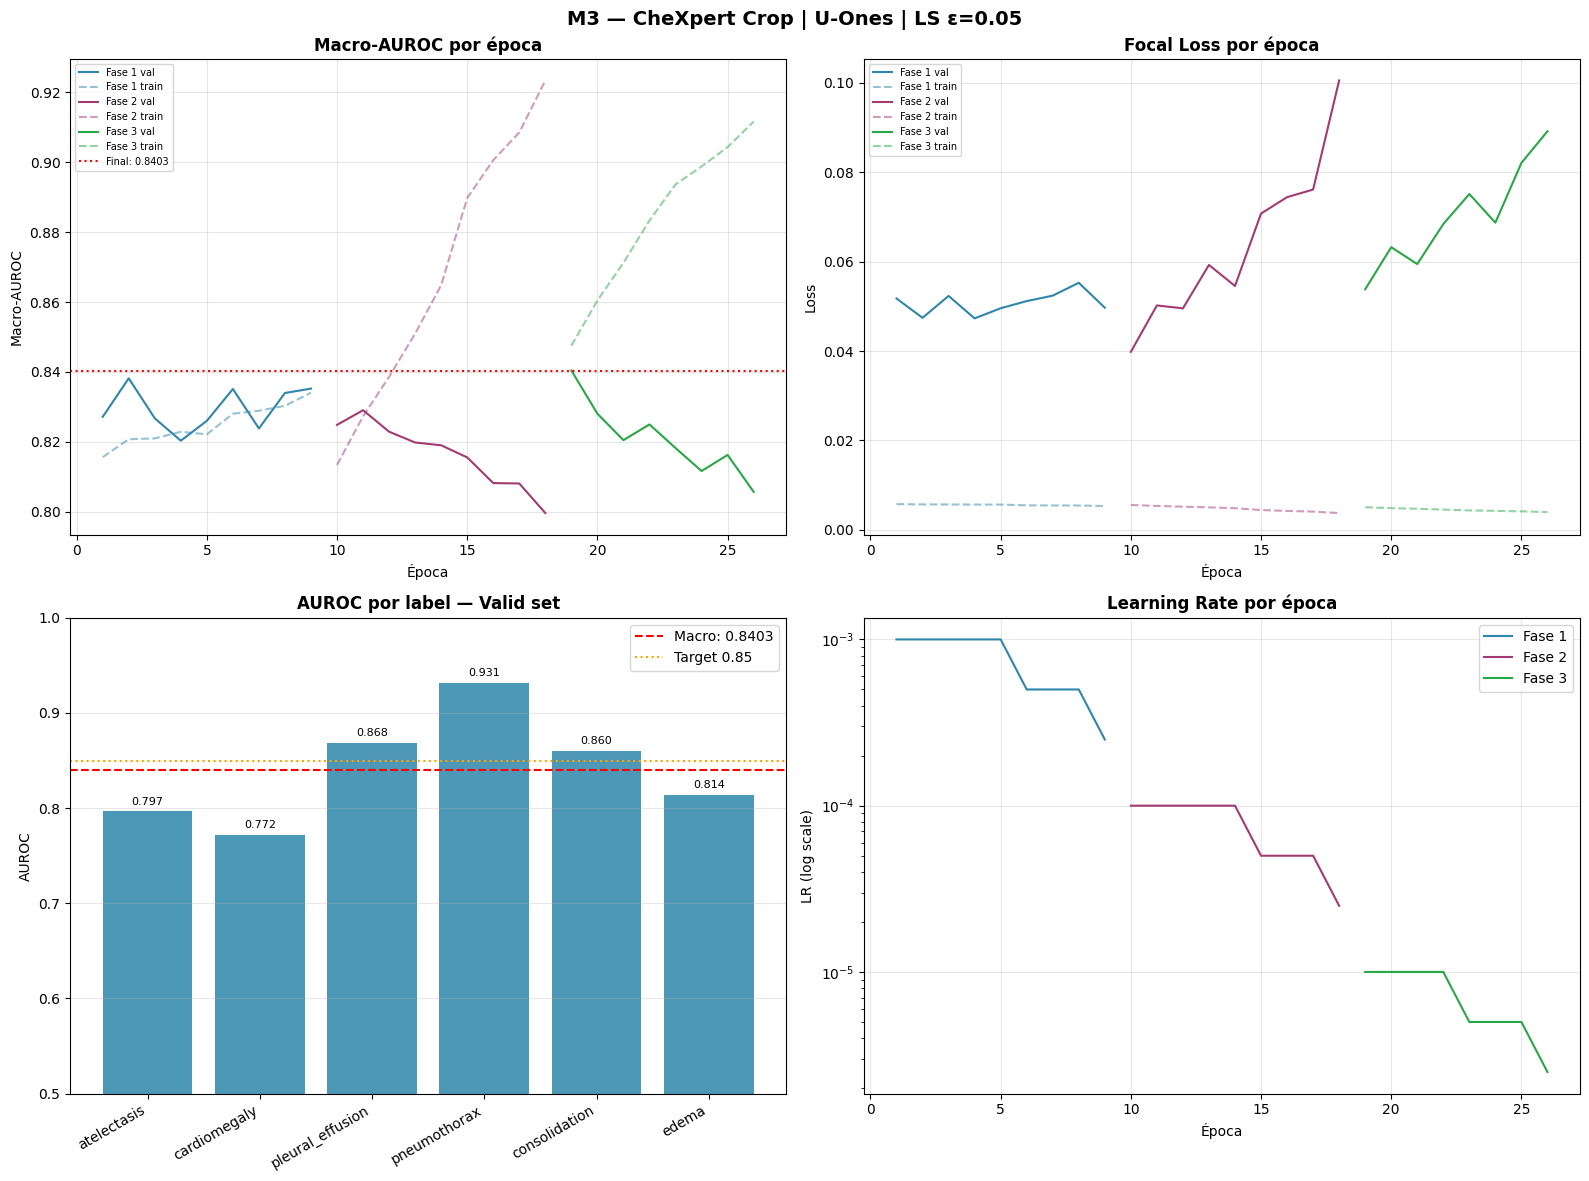

Curvas salvas.


In [18]:
def load_history(phase):
    log_path = f'{LOG_DIR}/{PREFIX}_fase{phase}_history.csv'
    if os.path.exists(log_path):
        return pd.read_csv(log_path)
    return None

hist_p1 = load_history(1)
hist_p2 = load_history(2)
hist_p3 = load_history(3)

if 'macro_auroc' not in dir() or 'per_label' not in dir():
    with open(f'{OUT_DIR}/m3_results.json') as f:
        res = json.load(f)
    macro_auroc = res['macro_auroc']
    per_label   = res['per_label_auroc']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f'M3 — CheXpert Crop | U-Ones | LS ε={LABEL_SMOOTHING_EPSILON}',
             fontsize=14, fontweight='bold')
colors = {'Fase 1': '#2E86AB', 'Fase 2': '#A23B72', 'Fase 3': '#28A745'}

def plot_metric(ax, metric, val_metric, title, ylabel):
    offset = 0
    for fase, hist in [('Fase 1',hist_p1),('Fase 2',hist_p2),('Fase 3',hist_p3)]:
        if hist is None: continue
        epochs = range(offset+1, offset+len(hist)+1)
        ax.plot(epochs, hist[val_metric], label=f'{fase} val', color=colors[fase])
        if metric in hist.columns:
            ax.plot(epochs, hist[metric], label=f'{fase} train',
                    color=colors[fase], linestyle='--', alpha=0.5)
        offset += len(hist)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Época'); ax.set_ylabel(ylabel)
    ax.legend(fontsize=7); ax.grid(alpha=0.3)

plot_metric(axes[0,0], 'macro_auroc', 'val_macro_auroc', 'Macro-AUROC por época', 'Macro-AUROC')
axes[0,0].axhline(y=macro_auroc, color='red', linestyle=':', label=f'Final: {macro_auroc:.4f}')
axes[0,0].legend(fontsize=7)

plot_metric(axes[0,1], 'loss', 'val_loss', 'Focal Loss por época', 'Loss')

ax3 = axes[1,0]
bars = ax3.bar(per_label.keys(), per_label.values(), color='#2E86AB', alpha=0.85)
ax3.axhline(y=macro_auroc, color='red', linestyle='--', label=f'Macro: {macro_auroc:.4f}')
ax3.axhline(y=0.85, color='orange', linestyle=':', label='Target 0.85')
ax3.set_title('AUROC por label — Valid set', fontweight='bold')
ax3.set_ylabel('AUROC'); ax3.set_ylim(0.5, 1.0)
ax3.legend(); ax3.grid(axis='y', alpha=0.3)
plt.sca(ax3); plt.xticks(rotation=30, ha='right')
for bar, val in zip(bars, per_label.values()):
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
             f'{val:.3f}', ha='center', va='bottom', fontsize=8)

ax4 = axes[1,1]
offset = 0
for fase, hist in [('Fase 1',hist_p1),('Fase 2',hist_p2),('Fase 3',hist_p3)]:
    if hist is None: continue
    col = 'lr' if 'lr' in hist.columns else ('learning_rate' if 'learning_rate' in hist.columns else None)
    if col:
        epochs = range(offset+1, offset+len(hist)+1)
        ax4.semilogy(epochs, hist[col], label=fase, color=colors[fase])
    offset += len(hist)
ax4.set_title('Learning Rate por época', fontweight='bold')
ax4.set_xlabel('Época'); ax4.set_ylabel('LR (log scale)')
ax4.legend(); ax4.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/m3_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Curvas salvas.')

In [4]:
# ── Salva modelo final ────────────────────────────────────────────────────────
if 'best_model' not in dir():
    CKPT_P3 = f'{CKPT_DIR}/{PREFIX}_fase3_best.keras'
    best_model = tf.keras.models.load_model(CKPT_P3, custom_objects=CUSTOM_OBJECTS)
    print('Modelo carregado do checkpoint P3.')

if 'macro_auroc' not in dir():
    with open(f'{OUT_DIR}/m3_results.json') as f:
        res = json.load(f); macro_auroc = res['macro_auroc']

final_path = f'{OUT_DIR}/m3_final.keras'
best_model.save(final_path)
print(f'Modelo final salvo: {final_path}')
print(f'\n{"="*55}')
print(f'M3 Crop U-Ones LS(ε={LABEL_SMOOTHING_EPSILON}) — RESUMO FINAL')
print(f'{"="*55}')
print(f'  Macro-AUROC : {macro_auroc:.4f}')
print(f'  Target      : 0.85–0.92')
print(f'  Status      : {"Atingido" if macro_auroc >= 0.85 else "Abaixo do target"}')
print(f'  LS epsilon  : {LABEL_SMOOTHING_EPSILON}')
print(f'  Modelo      : {final_path}')
print(f'{"="*55}')

NameError: name 'CUSTOM_OBJECTS' is not defined

## SEÇÃO 11 — Relatório Automático via Claude API

In [5]:
!pip install -q anthropic
import anthropic, time

API_KEY = '<API_KEY>'
client  = anthropic.Anthropic(api_key=API_KEY)

if 'macro_auroc' not in dir() or 'per_label' not in dir():
    with open(f'{OUT_DIR}/m3_results.json') as f:
        res = json.load(f)
    macro_auroc = res['macro_auroc']
    per_label   = res['per_label_auroc']

def load_history(phase):
    log_path = f'{LOG_DIR}/{PREFIX}_fase{phase}_history.csv'
    if os.path.exists(log_path):
        df = pd.read_csv(log_path)
        col = 'lr' if 'lr' in df.columns else ('learning_rate' if 'learning_rate' in df.columns else None)
        if col and col != 'lr':
            df = df.rename(columns={col: 'lr'})
        return df
    return None

def hist_summary(hist, phase):
    if hist is None: return f'Fase {phase}: sem dados'
    best_val = hist['val_macro_auroc'].max()
    best_ep  = hist['val_macro_auroc'].idxmax() + 1
    lr_str   = f'{float(hist["lr"].iloc[-1]):.2e}' if 'lr' in hist.columns else 'N/A'
    return (f'Fase {phase}: {len(hist)} epochs | '
            f'Melhor val_macro_auroc={best_val:.4f} (epoch {best_ep}) | LR final={lr_str}')

hist_p1 = load_history(1)
hist_p2 = load_history(2)
hist_p3 = load_history(3)

# Carrega M1 e M2 para comparação tripla
try:
    with open(f'{BASE_DRIVE}/datasets_pi_2026/modelos/M1_NIH/m1_results.json') as f:
        m1_res = json.load(f)
    m1_macro = m1_res['macro_auroc']; m1_pl = m1_res['per_label_auroc']
except Exception:
    m1_macro = None; m1_pl = {}

try:
    with open(f'{BASE_DRIVE}/datasets_pi_2026/modelos/M2_NIH_CheXpert_Crop_UIgnore/m2_crop_results.json') as f:
        m2_res = json.load(f)
    m2_macro = m2_res['macro_auroc']; m2_pl = m2_res['per_label_auroc']
except Exception:
    m2_macro = None; m2_pl = {}

label_lines = []
for lbl in LABELS:
    m1v = m1_pl.get(lbl, 0); m2v = m2_pl.get(lbl, 0); m3v = per_label.get(lbl, 0)
    label_lines.append(
        f'  {lbl:<22}: M1={m1v:.4f} | M2_Crop={m2v:.4f} | M3={m3v:.4f} | '
        f'ΔM2→M3={m3v-m2v:+.4f} | ΔM1→M3={m3v-m1v:+.4f}'
    )

# ── Variáveis auxiliares para o f-string ──────────────────────────────────────
label_table   = '\n'.join(label_lines)
separador     = '─' * 70
ls_target_pos = 1.0 - LABEL_SMOOTHING_EPSILON
ls_target_neg = LABEL_SMOOTHING_EPSILON
m1_str        = f'{m1_macro:.4f}' if m1_macro else 'N/A'
m2_str        = f'{m2_macro:.4f}' if m2_macro else 'N/A'
delta_m2_m3   = f'{macro_auroc - m2_macro:+.4f}' if m2_macro else 'N/A'
status_str    = 'Atingido' if macro_auroc >= 0.85 else 'Abaixo do target'

context = f"""
MODELO: M3 — Xception 512×512 | Fine-tuning NIH→CheXpert | Center Crop | U-Ones | Label Smoothing ε={LABEL_SMOOTHING_EPSILON}
OBJETIVO: Avaliar impacto da política U-Ones (-1→+1) + Label Smoothing vs M2 U-Ignore

CONFIGURAÇÃO:
  Backbone       : Xception (pesos M2_Crop como ponto de partida)
  Preprocessing  : Center Crop 2320×2320 → 512×512 PNG
  Política -1    : U-Ones — labels incertos convertidos para +1 (vs U-Ignore que descartava)
  Label Smoothing: epsilon={LABEL_SMOOTHING_EPSILON} (targets: 1→{ls_target_pos}, 0→{ls_target_neg})
  Loss           : Focal Loss LS γ=2.0 α=0.25 + pesos sobre positivos efetivos
  Label weights  : recalculados sobre positivos efetivos (confirmados + incertos convertidos)
  Dataset valid  : Stanford CheXpert 159 imagens

POSITIVOS EFETIVOS U-ONES (confirmados + incertos convertidos):
  atelectasis    : ~53.604 efetivos (vs 19.865 U-Ignore)
  consolidation  : ~40.725 efetivos (vs 12.983 U-Ignore)
  edema          : ~40.086 efetivos (vs 27.102 U-Ignore)
  pleural_effusion: ~49.380 efetivos (vs 37.752 U-Ignore)
  cardiomegaly   : ~25.591 efetivos (vs 17.504 U-Ignore)
  pneumothorax   : ~18.555 efetivos (vs 15.410 U-Ignore)

ESTRATÉGIA DE TREINO:
  {hist_summary(hist_p1, 1)}
  {hist_summary(hist_p2, 2)}
  {hist_summary(hist_p3, 3)}

RESULTADOS — COMPARAÇÃO M1 | M2 Crop U-Ignore | M3 Crop U-Ones:
{label_table}
  {separador}
  M1  Macro-AUROC : {m1_str}
  M2  Macro-AUROC : {m2_str}
  M3  Macro-AUROC : {macro_auroc:.4f}
  ΔM2→M3          : {delta_m2_m3}
  Target          : 0.85–0.92
  Status          : {status_str}
"""

prompt = f"""Você é um pesquisador sênior em visão computacional médica.

Abaixo estão os resultados do modelo M3 — ablation de política de labels incertos (U-Ones vs U-Ignore) com Label Smoothing, parte do ablation study de classificação multi-label de radiografias de tórax.

{context}

Produza um relatório técnico estruturado cobrindo:

1. **Resumo executivo**: delta M2→M3, o impacto do U-Ones foi positivo ou negativo?
2. **Impacto do U-Ones por label**: quais labels mais ganharam/perderam ao incluir os incertos como positivos? Relacionar com o volume de incertos convertidos e a qualidade esperada dos -1 para cada patologia
3. **Papel do Label Smoothing**: o epsilon={LABEL_SMOOTHING_EPSILON} foi adequado? Sugestões para iteração
4. **Análise das fases de treino**: overfitting, resposta ao scheduler, comportamento vs M2
5. **Labels de atenção**: Atelectasis (maior potencial, maior risco) e Consolidation (maior volume relativo de incertos)
6. **Comparação M1→M2→M3**: trajetória do ablation — o que cada etapa explicou?
7. **Expectativa para M4**: com base nos resultados do M3, quais decisões para a próxima etapa
8. **Pontos de atenção e riscos**: o que os resultados podem ou não garantir

Seja direto e técnico. Cite os números. Responda em português brasileiro."""

print('Enviando para Claude API...')
t0 = time.time()
message = client.messages.create(
    model='claude-sonnet-4-6', max_tokens=8192,
    messages=[{'role': 'user', 'content': prompt}]
)
relatorio = message.content[0].text
elapsed   = time.time() - t0
print(f'Resposta em {elapsed:.1f}s | {message.usage.input_tokens} in | {message.usage.output_tokens} out')

print('\n' + '='*65)
print('RELATÓRIO M3 — Claude Sonnet')
print('='*65)
print(relatorio)

report_path = f'{OUT_DIR}/m3_relatorio_claude.txt'
with open(report_path, 'w', encoding='utf-8') as f:
    f.write(context + '\n\n' + '='*65 + '\nRELATÓRIO CLAUDE\n' + '='*65 + '\n\n' + relatorio)
print(f'\nRelatório salvo: {report_path}')

Enviando para Claude API...
Resposta em 128.7s | 1537 in | 6562 out

RELATÓRIO M3 — Claude Sonnet
# Relatório Técnico — Ablation M3: U-Ones + Label Smoothing
## Xception 512×512 | Fine-tuning NIH→CheXpert | Center Crop

---

## 1. Resumo Executivo

O modelo M3 registrou **Macro-AUROC = 0.8403**, representando uma **queda de −0.0307 em relação ao M2_Crop (0.8710)**. O impacto da política U-Ones, combinada com Label Smoothing ε=0.05, foi **predominantemente negativo** nesta configuração.

Dos seis labels avaliados, **cinco apresentaram queda** em relação ao M2 e apenas **pneumothorax registrou ganho** (+0.0066). As quedas mais expressivas ocorreram em **edema (−0.0812)**, **cardiomegaly (−0.0538)** e **consolidation (−0.0332)**. O resultado permanece **abaixo do target de 0.85–0.92**, embora ainda represente ganho substancial sobre o M1 baseline (+0.0706 em Macro-AUROC).

A hipótese central — de que incluir exemplos incertos como positivos enriqueceria o sinal de treino — **não se confir